## Step 1: Load and Explore Data
### 1.1 Load the Dataset

In [1]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv('../data/aqi_data.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nFirst 10 rows:")
print(df.head(10))

Dataset Shape: (3406, 11)

First 10 rows:
  country           state               city  \
0   India  Andhra_Pradesh           Tirumala   
1   India  Andhra_Pradesh           Tirumala   
2   India  Andhra_Pradesh           Tirupati   
3   India  Andhra_Pradesh           Tirupati   
4   India  Andhra_Pradesh            Nellore   
5   India  Andhra_Pradesh            Nellore   
6   India  Andhra_Pradesh            Nellore   
7   India  Andhra_Pradesh              Eluru   
8   India  Andhra_Pradesh             Guntur   
9   India  Andhra_Pradesh  Rajamahendravaram   

                                          station          last_update  \
0                     Toll Gate, Tirumala - APPCB  31-03-2026 08:00:00   
1                     Toll Gate, Tirumala - APPCB  31-03-2026 08:00:00   
2                 Vaikuntapuram, Tirupati - APPCB  31-03-2026 08:00:00   
3                 Vaikuntapuram, Tirupati - APPCB  31-03-2026 08:00:00   
4                Ambedkar Nagar, Nellore - APPCB   31-03-20

## 1.2 Understand the Structure

In [2]:
# Basic info
print("\nColumn Info:")
print(df.dtypes)

print("\nUnique Values:")
print(f"Countries: {df['country'].nunique()}")
print(f"States: {df['state'].nunique()}")
print(f"Cities: {df['city'].nunique()}")
print(f"Stations: {df['station'].nunique()}")
print(f"Pollutants: {df['pollutant_id'].unique()}")

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())


Column Info:
country           object
state             object
city              object
station           object
last_update       object
latitude         float64
longitude        float64
pollutant_id      object
pollutant_min    float64
pollutant_max    float64
pollutant_avg    float64
dtype: object

Unique Values:
Countries: 1
States: 30
Cities: 262
Stations: 511
Pollutants: ['CO' 'OZONE' 'NO2' 'SO2' 'PM10' 'NH3' 'PM2.5']

Missing Values:
country            0
state              0
city               0
station            0
last_update        0
latitude           0
longitude          0
pollutant_id       0
pollutant_min    270
pollutant_max    270
pollutant_avg    270
dtype: int64


## Step 2: Transform Data
### 2.1 Convert Date Format

In [3]:
# Convert last_update to datetime
df['last_update'] = pd.to_datetime(df['last_update'], format='%d-%m-%Y %H:%M:%S')

print(f"Date Range: {df['last_update'].min()} to {df['last_update'].max()}")

Date Range: 2026-03-31 08:00:00 to 2026-03-31 08:00:00


## 2.2 Pivot from Long to Wide Format

In [4]:
# Pivot: One row per station with all pollutants as columns
df_wide = df.pivot_table(
    index=['country', 'state', 'city', 'station', 'last_update', 'latitude', 'longitude'],
    columns='pollutant_id',
    values='pollutant_avg',
    aggfunc='mean'
).reset_index()

# Flatten column names
df_wide.columns.name = None

print(f"\nAfter pivoting:")
print(f"Shape: {df_wide.shape}")
print(f"Columns: {df_wide.columns.tolist()}")


After pivoting:
Shape: (490, 14)
Columns: ['country', 'state', 'city', 'station', 'last_update', 'latitude', 'longitude', 'CO', 'NH3', 'NO2', 'OZONE', 'PM10', 'PM2.5', 'SO2']


## 2.3 Verify Transformation

In [5]:
# Sample check
sample_station = df_wide.iloc[0]
print("\nSample Station Data:")
print(f"City: {sample_station['city']}")
print(f"PM2.5: {sample_station.get('PM2.5', 'N/A')}")
print(f"PM10: {sample_station.get('PM10', 'N/A')}")
print(f"NO2: {sample_station.get('NO2', 'N/A')}")


Sample Station Data:
City: Amaravati
PM2.5: 36.0
PM10: 54.0
NO2: 8.0


## Step 3: Calculate AQI
### 3.1 Understanding Indian AQI Calculation
Indian CPCB AQI Method:

* Calculate sub-index for each pollutant
* AQI = Maximum of all sub-indices
* Breakpoints defined by CPCB standards

## 3.2 Implement AQI Calculation

In [6]:
def calculate_aqi(pm25, pm10, no2, so2, co, o3):
    """
    Calculate AQI based on Indian CPCB standards
    Returns the maximum sub-index from all pollutants
    """
    
    def get_aqi_pm25(pm25):
        """PM2.5 sub-index calculation"""
        if pd.isna(pm25): return np.nan
        if pm25 <= 30: return pm25 * 50 / 30
        elif pm25 <= 60: return 50 + (pm25 - 30) * 50 / 30
        elif pm25 <= 90: return 100 + (pm25 - 60) * 100 / 30
        elif pm25 <= 120: return 200 + (pm25 - 90) * 100 / 30
        elif pm25 <= 250: return 300 + (pm25 - 120) * 100 / 130
        else: return 400 + (pm25 - 250) * 100 / 130
    
    def get_aqi_pm10(pm10):
        """PM10 sub-index calculation"""
        if pd.isna(pm10): return np.nan
        if pm10 <= 50: return pm10
        elif pm10 <= 100: return 50 + (pm10 - 50) * 50 / 50
        elif pm10 <= 250: return 100 + (pm10 - 100) * 100 / 150
        elif pm10 <= 350: return 200 + (pm10 - 250) * 100 / 100
        elif pm10 <= 430: return 300 + (pm10 - 350) * 100 / 80
        else: return 400 + (pm10 - 430) * 100 / 80
    
    def get_aqi_no2(no2):
        """NO2 sub-index calculation"""
        if pd.isna(no2): return np.nan
        if no2 <= 40: return no2 * 50 / 40
        elif no2 <= 80: return 50 + (no2 - 40) * 50 / 40
        elif no2 <= 180: return 100 + (no2 - 80) * 100 / 100
        elif no2 <= 280: return 200 + (no2 - 180) * 100 / 100
        elif no2 <= 400: return 300 + (no2 - 280) * 100 / 120
        else: return 400 + (no2 - 400) * 100 / 120
    
    def get_aqi_so2(so2):
        """SO2 sub-index calculation"""
        if pd.isna(so2): return np.nan
        if so2 <= 40: return so2 * 50 / 40
        elif so2 <= 80: return 50 + (so2 - 40) * 50 / 40
        elif so2 <= 380: return 100 + (so2 - 80) * 100 / 300
        elif so2 <= 800: return 200 + (so2 - 380) * 100 / 420
        elif so2 <= 1600: return 300 + (so2 - 800) * 100 / 800
        else: return 400 + (so2 - 1600) * 100 / 800
    
    def get_aqi_co(co):
        """CO sub-index calculation"""
        if pd.isna(co): return np.nan
        if co <= 1.0: return co * 50 / 1.0
        elif co <= 2.0: return 50 + (co - 1.0) * 50 / 1.0
        elif co <= 10: return 100 + (co - 2.0) * 100 / 8.0
        elif co <= 17: return 200 + (co - 10) * 100 / 7.0
        elif co <= 34: return 300 + (co - 17) * 100 / 17
        else: return 400 + (co - 34) * 100 / 17
    
    def get_aqi_o3(o3):
        """O3 (Ozone) sub-index calculation"""
        if pd.isna(o3): return np.nan
        if o3 <= 50: return o3
        elif o3 <= 100: return 50 + (o3 - 50) * 50 / 50
        elif o3 <= 168: return 100 + (o3 - 100) * 100 / 68
        elif o3 <= 208: return 200 + (o3 - 168) * 100 / 40
        elif o3 <= 748: return 300 + (o3 - 208) * 100 / 540
        else: return 400 + (o3 - 748) * 100 / 540
    
    # Calculate all sub-indices
    aqi_pm25 = get_aqi_pm25(pm25)
    aqi_pm10 = get_aqi_pm10(pm10)
    aqi_no2 = get_aqi_no2(no2)
    aqi_so2 = get_aqi_so2(so2)
    aqi_co = get_aqi_co(co)
    aqi_o3 = get_aqi_o3(o3)
    
    # Return maximum sub-index
    return np.nanmax([aqi_pm25, aqi_pm10, aqi_no2, aqi_so2, aqi_co, aqi_o3])

# Apply to dataset
df_wide['AQI'] = df_wide.apply(
    lambda row: calculate_aqi(
        row.get('PM2.5', np.nan),
        row.get('PM10', np.nan),
        row.get('NO2', np.nan),
        row.get('SO2', np.nan),
        row.get('CO', np.nan),
        row.get('OZONE', np.nan)
    ),
    axis=1
)

print(f"\nAQI Statistics:")
print(df_wide['AQI'].describe())


AQI Statistics:
count     490.000000
mean      384.577014
std       167.156091
min        22.500000
25%       285.714286
50%       360.000000
75%       470.588235
max      1117.647059
Name: AQI, dtype: float64


## 3.3 AQI Categories

In [7]:
def get_aqi_category(aqi):
    """Categorize AQI based on Indian standards"""
    if pd.isna(aqi): return 'Unknown'
    elif aqi <= 50: return 'Good'
    elif aqi <= 100: return 'Satisfactory'
    elif aqi <= 200: return 'Moderate'
    elif aqi <= 300: return 'Poor'
    elif aqi <= 400: return 'Very Poor'
    else: return 'Severe'

df_wide['AQI_Category'] = df_wide['AQI'].apply(get_aqi_category)

print("\nAQI Distribution by Category:")
print(df_wide['AQI_Category'].value_counts())


AQI Distribution by Category:
AQI_Category
Severe          188
Very Poor       174
Poor             73
Moderate         39
Good              9
Satisfactory      7
Name: count, dtype: int64


## Step 4: Data Preprocessing
### 4.1 Handle Missing Values

In [8]:
# Remove rows without AQI
df_clean = df_wide[df_wide['AQI'].notna()].copy()

print(f"Rows with valid AQI: {len(df_clean)} / {len(df_wide)}")

# Fill missing pollutant values
pollutants = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'OZONE', 'NH3']

for pollutant in pollutants:
    if pollutant in df_clean.columns:
        median_val = df_clean[pollutant].median()
        missing_before = df_clean[pollutant].isna().sum()
        
        df_clean[pollutant] = df_clean[pollutant].fillna(median_val)
        
        print(f"{pollutant}: filled {missing_before} missing values with median {median_val:.2f}")

Rows with valid AQI: 490 / 490
PM2.5: filled 29 missing values with median 55.00
PM10: filled 33 missing values with median 81.00
NO2: filled 34 missing values with median 20.00
SO2: filled 53 missing values with median 12.00
CO: filled 20 missing values with median 28.00
OZONE: filled 41 missing values with median 15.00
NH3: filled 84 missing values with median 5.00


## 4.2 Outlier Detection

In [9]:
def detect_outliers(df, column):
    """Detect outliers using IQR method"""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    return len(outliers), lower, upper

for pollutant in ['PM2.5', 'PM10', 'NO2', 'AQI']:
    if pollutant in df_clean.columns:
        n_outliers, lower, upper = detect_outliers(df_clean, pollutant)
        print(f"{pollutant}: {n_outliers} outliers (range: {lower:.1f} - {upper:.1f})")

PM2.5: 41 outliers (range: -30.1 - 146.9)
PM10: 31 outliers (range: -16.0 - 184.0)
NO2: 36 outliers (range: -16.5 - 59.5)
AQI: 16 outliers (range: 8.4 - 747.9)


## Step 5: Exploratory Data Analysis
### 5.1 AQI Distribution

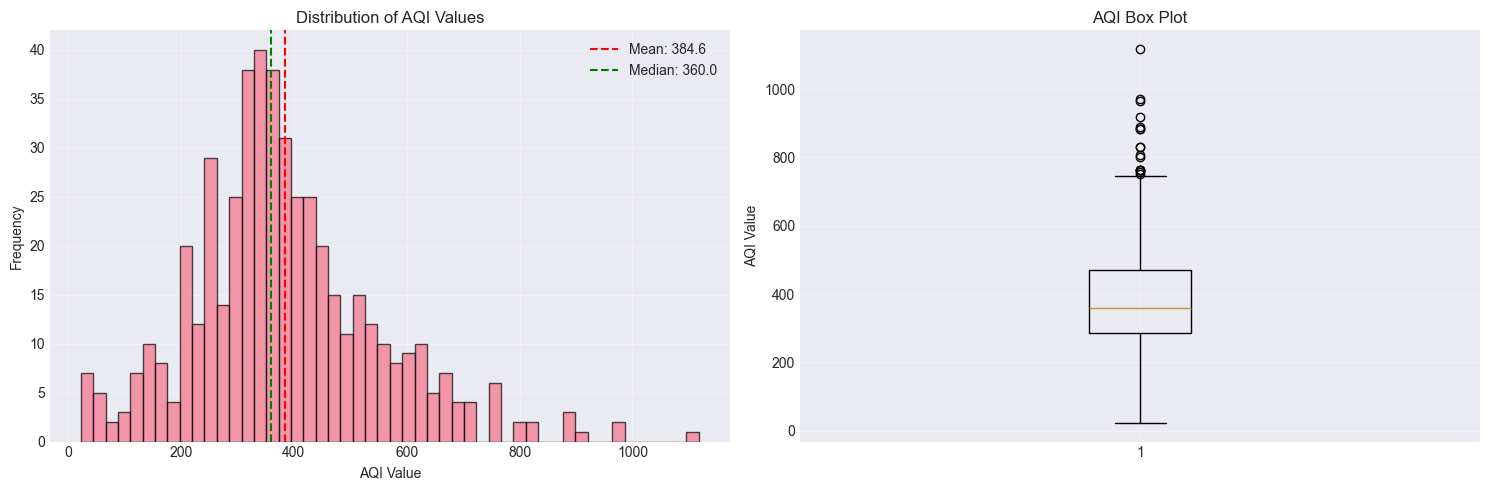

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df_clean['AQI'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(df_clean['AQI'].mean(), color='red', linestyle='--', 
                label=f'Mean: {df_clean["AQI"].mean():.1f}')
axes[0].axvline(df_clean['AQI'].median(), color='green', linestyle='--',
                label=f'Median: {df_clean["AQI"].median():.1f}')
axes[0].set_xlabel('AQI Value')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of AQI Values')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot
axes[1].boxplot(df_clean['AQI'])
axes[1].set_ylabel('AQI Value')
axes[1].set_title('AQI Box Plot')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../visualization/aqi_distribution.png', dpi=300)
plt.show()

## 5.2 Top Cities by AQI

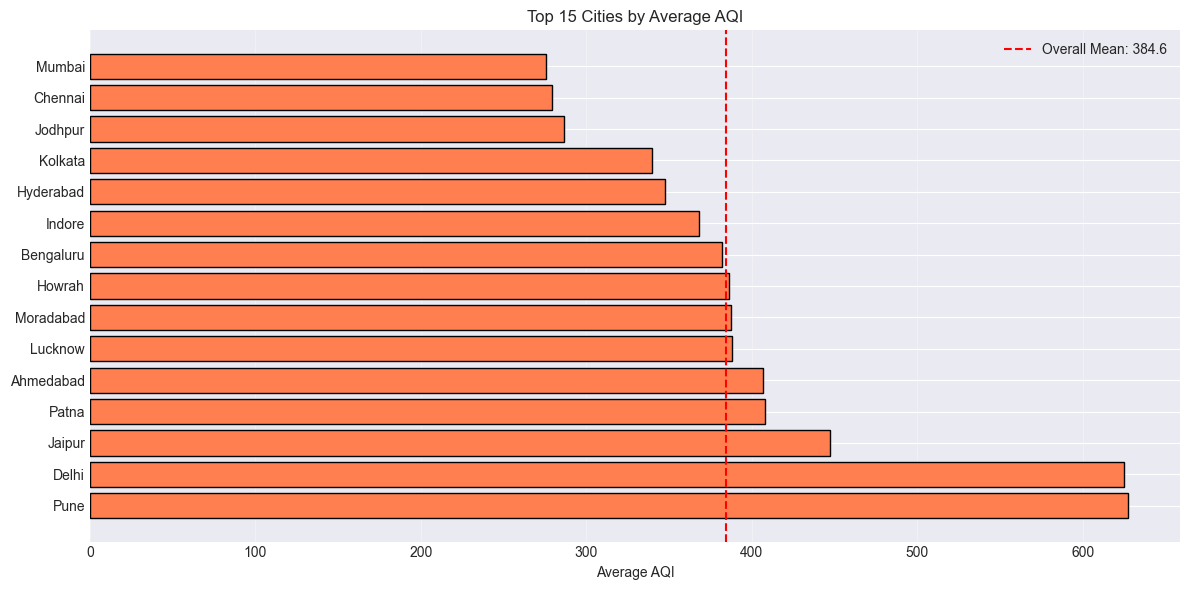


Top 10 Cities by AQI:
          city    mean_aqi     std_aqi  count
190       Pune  627.450980   93.240397      9
74       Delhi  625.000000  178.660038     44
106     Jaipur  447.058824  123.333177      6
183      Patna  407.843137   77.026636      6
2    Ahmedabad  407.090336  235.296603      8
140    Lucknow  388.095238  117.874230      6
156  Moradabad  387.622549  152.052293      6
101     Howrah  386.386555  160.771698      5
34   Bengaluru  382.166200  117.132562      9
104     Indore  368.389140   64.450018      5


In [11]:
# Get cities with at least 5 stations
city_aqi = df_clean.groupby('city').agg({
    'AQI': ['mean', 'std', 'count']
}).reset_index()

city_aqi.columns = ['city', 'mean_aqi', 'std_aqi', 'count']
city_aqi = city_aqi[city_aqi['count'] >= 5]
city_aqi = city_aqi.sort_values('mean_aqi', ascending=False).head(15)

plt.figure(figsize=(12, 6))
plt.barh(range(len(city_aqi)), city_aqi['mean_aqi'], 
         color='coral', edgecolor='black')
plt.yticks(range(len(city_aqi)), city_aqi['city'])
plt.xlabel('Average AQI')
plt.title('Top 15 Cities by Average AQI')
plt.axvline(df_clean['AQI'].mean(), color='red', linestyle='--',
            label=f'Overall Mean: {df_clean["AQI"].mean():.1f}')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../visualization/top_cities.png', dpi=300)
plt.show()

print("\nTop 10 Cities by AQI:")
print(city_aqi.head(10))

## 5.3 Correlation Analysis

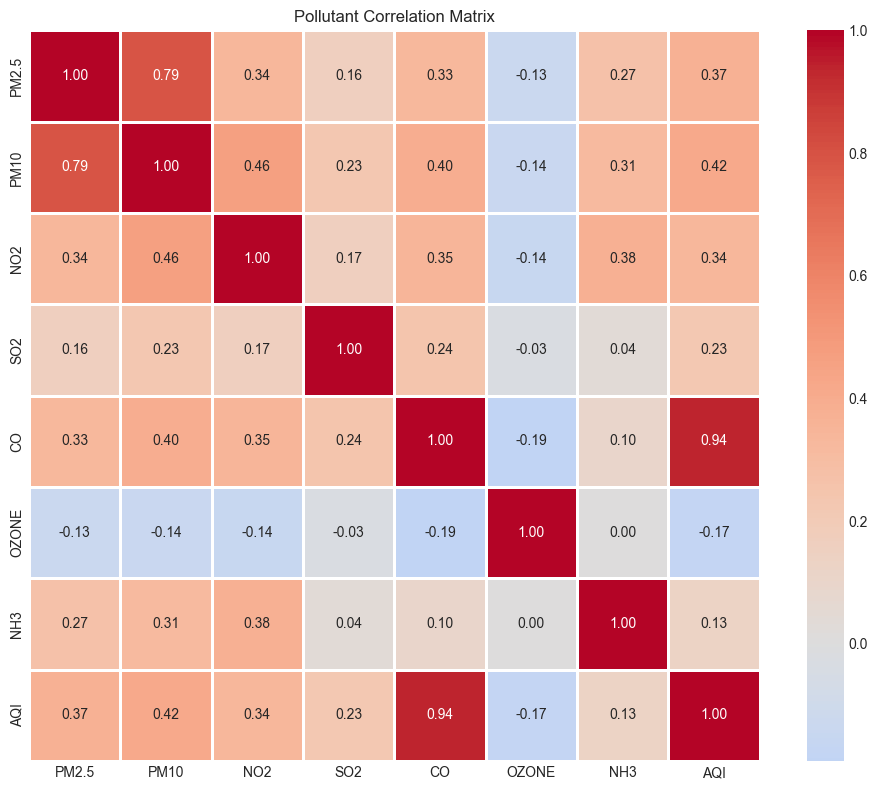


Correlation with AQI:
AQI      1.000000
CO       0.937336
PM10     0.421662
PM2.5    0.372521
NO2      0.342463
SO2      0.226192
NH3      0.131637
OZONE   -0.168772
Name: AQI, dtype: float64


In [12]:
# Correlation matrix
corr_features = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'OZONE', 'NH3', 'AQI']
corr_matrix = df_clean[corr_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1)
plt.title('Pollutant Correlation Matrix')
plt.tight_layout()
plt.savefig('../visualization/correlation_matrix.png', dpi=300)
plt.show()

print("\nCorrelation with AQI:")
print(corr_matrix['AQI'].sort_values(ascending=False))

## 5.4 Pollutant vs AQI Relationships

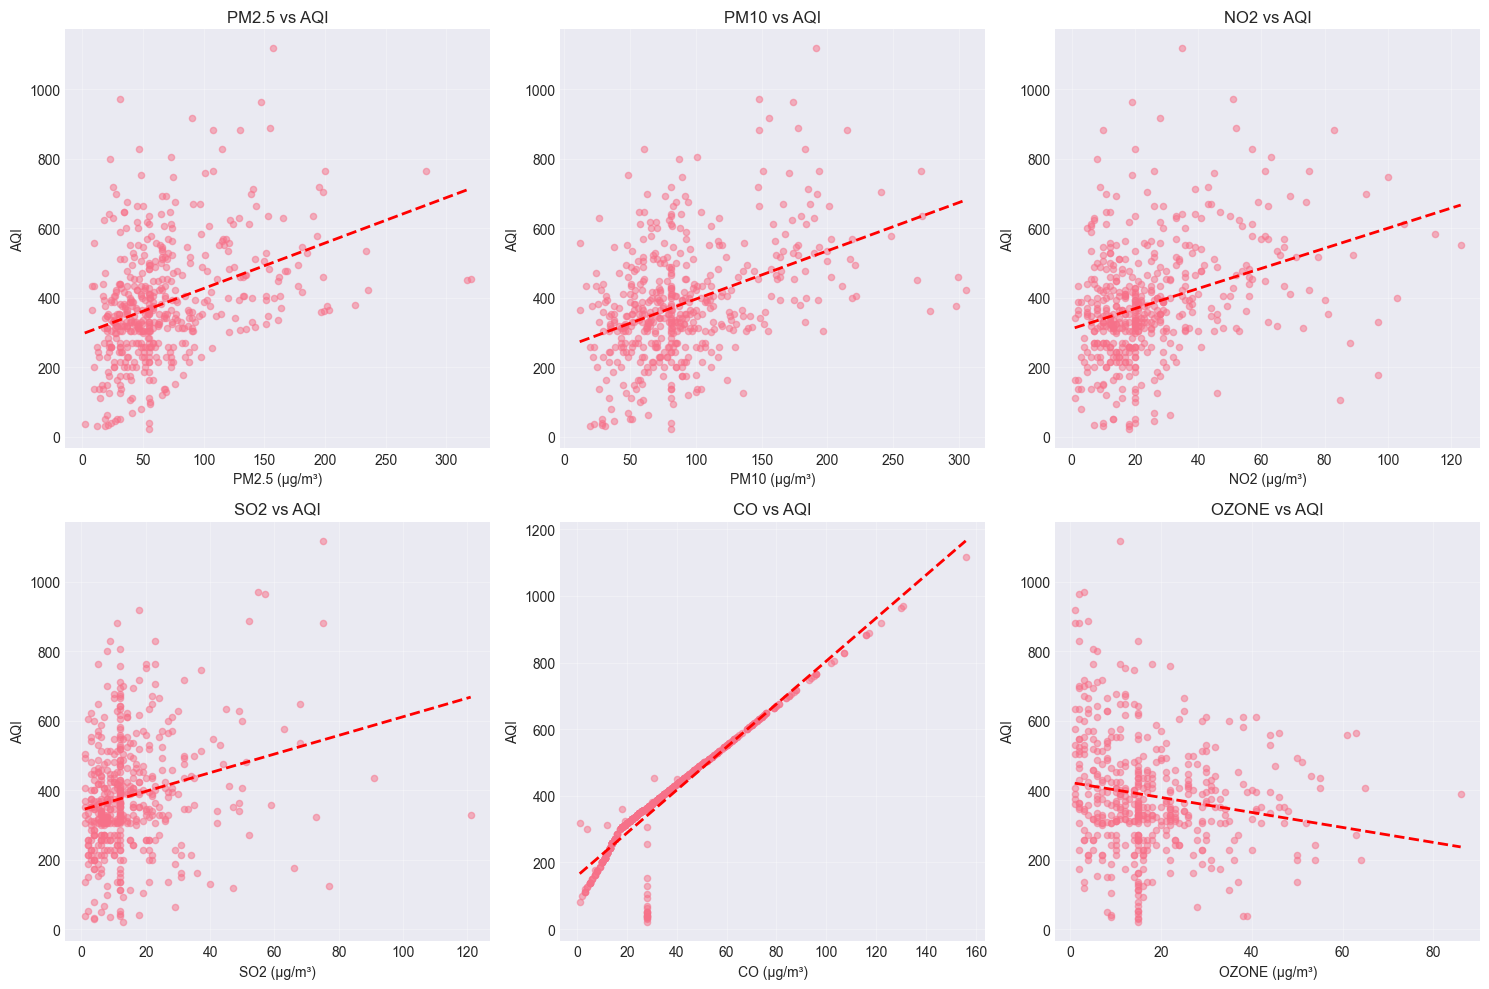

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

pollutants = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'OZONE']

for idx, pollutant in enumerate(pollutants):
    axes[idx].scatter(df_clean[pollutant], df_clean['AQI'], 
                     alpha=0.5, s=20)
    axes[idx].set_xlabel(f'{pollutant} (μg/m³)')
    axes[idx].set_ylabel('AQI')
    axes[idx].set_title(f'{pollutant} vs AQI')
    
    # Trend line
    z = np.polyfit(df_clean[pollutant], df_clean['AQI'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_clean[pollutant].min(), 
                         df_clean[pollutant].max(), 100)
    axes[idx].plot(x_line, p(x_line), "r--", linewidth=2)
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../visualization/pollutant_relationships.png', dpi=300)
plt.show()

## 5.5 State-wise Analysis

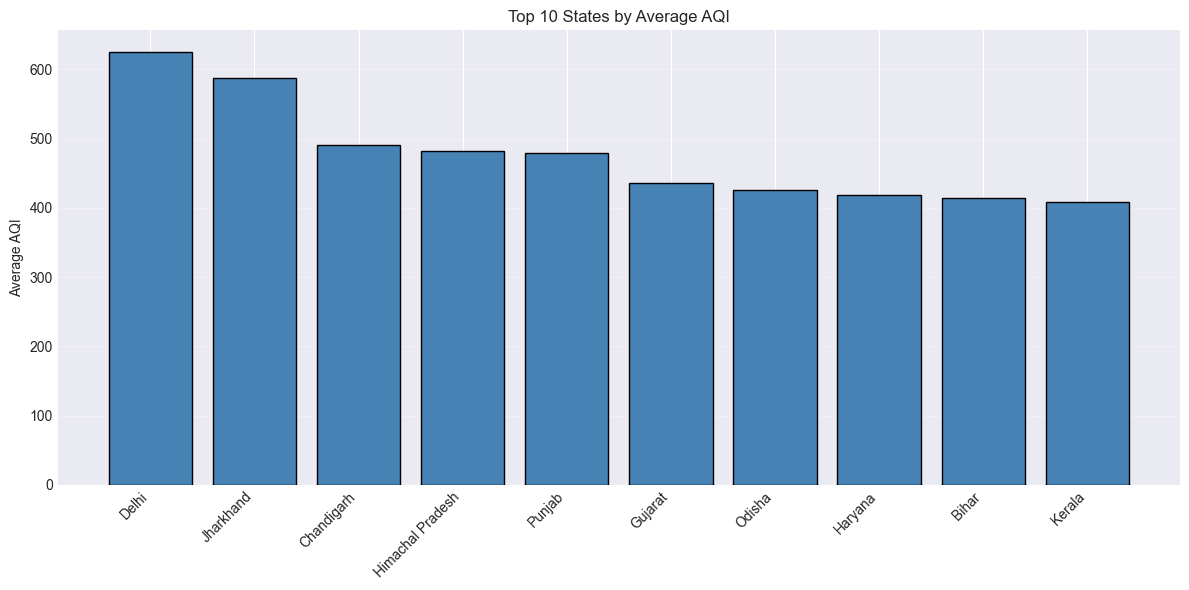

In [14]:
# Top states by average AQI
state_aqi = df_clean.groupby('state')['AQI'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.bar(range(len(state_aqi)), state_aqi.values, color='steelblue', edgecolor='black')
plt.xticks(range(len(state_aqi)), state_aqi.index, rotation=45, ha='right')
plt.ylabel('Average AQI')
plt.title('Top 10 States by Average AQI')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../visualization/state_comparison.png', dpi=300)
plt.show()

## Step 6: Feature Engineering
### 6.1 Pollutant Ratios

In [15]:
# PM2.5 to PM10 ratio
df_clean['PM_ratio'] = df_clean['PM2.5'] / (df_clean['PM10'] + 1)

# NOx to SOx ratio
df_clean['NOx_SOx_ratio'] = df_clean['NO2'] / (df_clean['SO2'] + 1)

print("Ratio features created:")
print(f"PM_ratio: {df_clean['PM_ratio'].describe()}")
print(f"NOx_SOx_ratio: {df_clean['NOx_SOx_ratio'].describe()}")

Ratio features created:
PM_ratio: count    490.000000
mean       0.733492
std        0.289069
min        0.083333
25%        0.539899
50%        0.700575
75%        0.898272
max        1.987805
Name: PM_ratio, dtype: float64
NOx_SOx_ratio: count    490.000000
mean       2.329170
std        2.473834
min        0.021739
25%        0.933333
50%        1.636364
75%        2.972222
max       27.500000
Name: NOx_SOx_ratio, dtype: float64


## 6.2 Pollutant Interactions

In [16]:
# Multiplicative interactions
df_clean['PM_NO2_interaction'] = df_clean['PM2.5'] * df_clean['NO2']
df_clean['PM_CO_interaction'] = df_clean['PM2.5'] * df_clean['CO']
df_clean['NO2_SO2_interaction'] = df_clean['NO2'] * df_clean['SO2']

print("\nInteraction features created")


Interaction features created


## 6.3 Combined Indices

In [17]:
# Total particulate matter
df_clean['Total_PM'] = df_clean['PM2.5'] + df_clean['PM10']

# Total gaseous pollutants
df_clean['Total_Gas'] = df_clean['NO2'] + df_clean['SO2'] + df_clean['CO']

print("\nCombined indices created:")
print(f"Total_PM range: {df_clean['Total_PM'].min():.1f} - {df_clean['Total_PM'].max():.1f}")
print(f"Total_Gas range: {df_clean['Total_Gas'].min():.1f} - {df_clean['Total_Gas'].max():.1f}")


Combined indices created:
Total_PM range: 20.0 - 585.0
Total_Gas range: 8.0 - 266.0


## 6.4 Geographical Features

In [18]:
from sklearn.preprocessing import LabelEncoder

# Encode state
le_state = LabelEncoder()
df_clean['state_encoded'] = le_state.fit_transform(df_clean['state'])

# Encode city (top 20, others = 'Other')
top_cities = df_clean['city'].value_counts().head(20).index
df_clean['city_category'] = df_clean['city'].apply(
    lambda x: x if x in top_cities else 'Other'
)
le_city = LabelEncoder()
df_clean['city_encoded'] = le_city.fit_transform(df_clean['city_category'])

# Rounded coordinates (cluster nearby stations)
df_clean['lat_rounded'] = np.round(df_clean['latitude'], 1)
df_clean['lon_rounded'] = np.round(df_clean['longitude'], 1)

print(f"\nGeographical encoding:")
print(f"States: {len(le_state.classes_)}")
print(f"City categories: {len(le_city.classes_)}")




Geographical encoding:
States: 30
City categories: 21


## 6.5 Summary of Features

In [19]:
feature_summary = pd.DataFrame({
    'Category': [
        'Original Pollutants',
        'Calculated Target',
        'Ratio Features',
        'Interaction Features',
        'Combined Indices',
        'Geographical Features'
    ],
    'Count': [7, 1, 2, 3, 2, 4],
    'Examples': [
        'PM2.5, PM10, NO2, SO2, CO, OZONE, NH3',
        'AQI',
        'PM_ratio, NOx_SOx_ratio',
        'PM_NO2_interaction, PM_CO_interaction, NO2_SO2_interaction',
        'Total_PM, Total_Gas',
        'state_encoded, city_encoded, latitude, longitude'
    ]
})

print("\n" + "="*80)
print("FEATURE ENGINEERING SUMMARY")
print("="*80)
print(feature_summary.to_string(index=False))
print(f"\nTotal features for modeling: {7 + 2 + 3 + 2 + 4} = 18 features")


FEATURE ENGINEERING SUMMARY
             Category  Count                                                   Examples
  Original Pollutants      7                      PM2.5, PM10, NO2, SO2, CO, OZONE, NH3
    Calculated Target      1                                                        AQI
       Ratio Features      2                                    PM_ratio, NOx_SOx_ratio
 Interaction Features      3 PM_NO2_interaction, PM_CO_interaction, NO2_SO2_interaction
     Combined Indices      2                                        Total_PM, Total_Gas
Geographical Features      4           state_encoded, city_encoded, latitude, longitude

Total features for modeling: 18 = 18 features


## Step 7: Model Building
### 7.1 Prepare Training Data

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Select features
feature_columns = [
    # Original pollutants
    'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'OZONE', 'NH3',
    # Engineered features
    'PM_ratio', 'NOx_SOx_ratio',
    'PM_NO2_interaction', 'PM_CO_interaction', 'NO2_SO2_interaction',
    'Total_PM', 'Total_Gas',
    # Geographical
    'state_encoded', 'city_encoded', 'latitude', 'longitude'
]

X = df_clean[feature_columns]
y = df_clean['AQI']

print(f"Feature matrix: {X.shape}")
print(f"Target: {y.shape}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain: {len(X_train)} samples")
print(f"Test: {len(X_test)} samples")

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_columns)

print("✓ Features scaled")

Feature matrix: (490, 18)
Target: (490,)

Train: 392 samples
Test: 98 samples
✓ Features scaled


## 7.2 Baseline Model

In [21]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Baseline: predict mean
baseline_pred = np.full(len(y_test), y_train.mean())
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)
baseline_mae = mean_absolute_error(y_test, baseline_pred)

print("\n" + "="*60)
print("BASELINE MODEL (Mean Prediction)")
print("="*60)
print(f"RMSE: {baseline_rmse:.2f}")
print(f"R²: {baseline_r2:.4f}")
print(f"MAE: {baseline_mae:.2f}")


BASELINE MODEL (Mean Prediction)
RMSE: 172.86
R²: -0.0245
MAE: 124.47


## 7.3 Random Forest Model

In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

print("\n" + "="*60)
print("TRAINING RANDOM FOREST")
print("="*60)

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=25,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

rf_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_rf_train = rf_model.predict(X_train_scaled)
y_pred_rf_test = rf_model.predict(X_test_scaled)

# Metrics
rf_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_rf_train))
rf_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf_test))
rf_train_r2 = r2_score(y_train, y_pred_rf_train)
rf_test_r2 = r2_score(y_test, y_pred_rf_test)
rf_test_mae = mean_absolute_error(y_test, y_pred_rf_test)

# Cross-validation
rf_cv_scores = cross_val_score(
    rf_model, X_train_scaled, y_train, 
    cv=5, scoring='neg_root_mean_squared_error'
)
rf_cv_rmse = -rf_cv_scores.mean()

print(f"Training RMSE: {rf_train_rmse:.2f}")
print(f"Test RMSE: {rf_test_rmse:.2f}")
print(f"CV RMSE (5-fold): {rf_cv_rmse:.2f} ± {rf_cv_scores.std():.2f}")
print(f"Training R²: {rf_train_r2:.4f}")
print(f"Test R²: {rf_test_r2:.4f}")
print(f"Test MAE: {rf_test_mae:.2f}")


TRAINING RANDOM FOREST
Training RMSE: 22.71
Test RMSE: 16.69
CV RMSE (5-fold): 46.36 ± 11.45
Training R²: 0.9812
Test R²: 0.9904
Test MAE: 5.98


## 7.4 XGBoost Model

In [23]:
import xgboost as xgb

print("\n" + "="*60)
print("TRAINING XGBOOST")
print("="*60)

xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_scaled, y_train, verbose=False)

# Predictions
y_pred_xgb_train = xgb_model.predict(X_train_scaled)
y_pred_xgb_test = xgb_model.predict(X_test_scaled)

# Metrics
xgb_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_xgb_train))
xgb_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb_test))
xgb_train_r2 = r2_score(y_train, y_pred_xgb_train)
xgb_test_r2 = r2_score(y_test, y_pred_xgb_test)
xgb_test_mae = mean_absolute_error(y_test, y_pred_xgb_test)

# Cross-validation
xgb_cv_scores = cross_val_score(
    xgb_model, X_train_scaled, y_train,
    cv=5, scoring='neg_root_mean_squared_error'
)
xgb_cv_rmse = -xgb_cv_scores.mean()

print(f"Training RMSE: {xgb_train_rmse:.2f}")
print(f"Test RMSE: {xgb_test_rmse:.2f}")
print(f"CV RMSE (5-fold): {xgb_cv_rmse:.2f} ± {xgb_cv_scores.std():.2f}")
print(f"Training R²: {xgb_train_r2:.4f}")
print(f"Test R²: {xgb_test_r2:.4f}")
print(f"Test MAE: {xgb_test_mae:.2f}")


TRAINING XGBOOST
Training RMSE: 0.00
Test RMSE: 24.47
CV RMSE (5-fold): 51.42 ± 10.51
Training R²: 1.0000
Test R²: 0.9795
Test MAE: 16.33


## 7.5 Hyperparameter Tuning

In [24]:
from sklearn.model_selection import GridSearchCV

print("\n" + "="*60)
print("HYPERPARAMETER TUNING (XGBoost)")
print("="*60)
print("This may take a few minutes...")

param_grid = {
    'max_depth': [6, 8, 10],
    'learning_rate': [0.05, 0.1, 0.15],
    'n_estimators': [200, 300],
    'subsample': [0.8, 0.9]
}

xgb_grid = GridSearchCV(
    xgb.XGBRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

xgb_grid.fit(X_train_scaled, y_train)

print(f"\nBest Parameters: {xgb_grid.best_params_}")
print(f"Best CV RMSE: {-xgb_grid.best_score_:.2f}")

# Final model
xgb_model_tuned = xgb_grid.best_estimator_
y_pred_xgb_tuned = xgb_model_tuned.predict(X_test_scaled)

xgb_tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned))
xgb_tuned_r2 = r2_score(y_test, y_pred_xgb_tuned)
xgb_tuned_mae = mean_absolute_error(y_test, y_pred_xgb_tuned)

print(f"\nTuned Model Performance:")
print(f"Test RMSE: {xgb_tuned_rmse:.2f}")
print(f"Test R²: {xgb_tuned_r2:.4f}")
print(f"Test MAE: {xgb_tuned_mae:.2f}")


HYPERPARAMETER TUNING (XGBoost)
This may take a few minutes...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best Parameters: {'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 300, 'subsample': 0.8}
Best CV RMSE: 45.44

Tuned Model Performance:
Test RMSE: 11.04
Test R²: 0.9958
Test MAE: 4.75


## Step 8: Model Evaluation
### 8.1 Model Comparison

In [25]:
# Create comparison table
results = pd.DataFrame({
    'Model': ['Baseline', 'Random Forest', 'XGBoost', 'XGBoost Tuned'],
    'Test RMSE': [baseline_rmse, rf_test_rmse, xgb_test_rmse, xgb_tuned_rmse],
    'Test R²': [baseline_r2, rf_test_r2, xgb_test_r2, xgb_tuned_r2],
    'Test MAE': [baseline_mae, rf_test_mae, xgb_test_mae, xgb_tuned_mae],
    'CV RMSE': ['-', f'{rf_cv_rmse:.2f}', f'{xgb_cv_rmse:.2f}', f'{-xgb_grid.best_score_:.2f}']
})

print("\n" + "="*80)
print("MODEL PERFORMANCE COMPARISON")
print("="*80)
print(results.to_string(index=False))
print("="*80)

# Best model
best_idx = results['Test RMSE'].iloc[1:].argmin() + 1
print(f"\n🏆 Best Model: {results.iloc[best_idx]['Model']}")
print(f"   RMSE: {results.iloc[best_idx]['Test RMSE']:.2f}")
print(f"   R²: {results.iloc[best_idx]['Test R²']:.4f}")


MODEL PERFORMANCE COMPARISON
        Model  Test RMSE   Test R²   Test MAE CV RMSE
     Baseline 172.861631 -0.024517 124.466456       -
Random Forest  16.693547  0.990445   5.984600   46.36
      XGBoost  24.466883  0.979475  16.334668   51.42
XGBoost Tuned  11.042915  0.995819   4.754767   45.44

🏆 Best Model: XGBoost Tuned
   RMSE: 11.04
   R²: 0.9958


## 8.2 Predicted vs Actual Plot

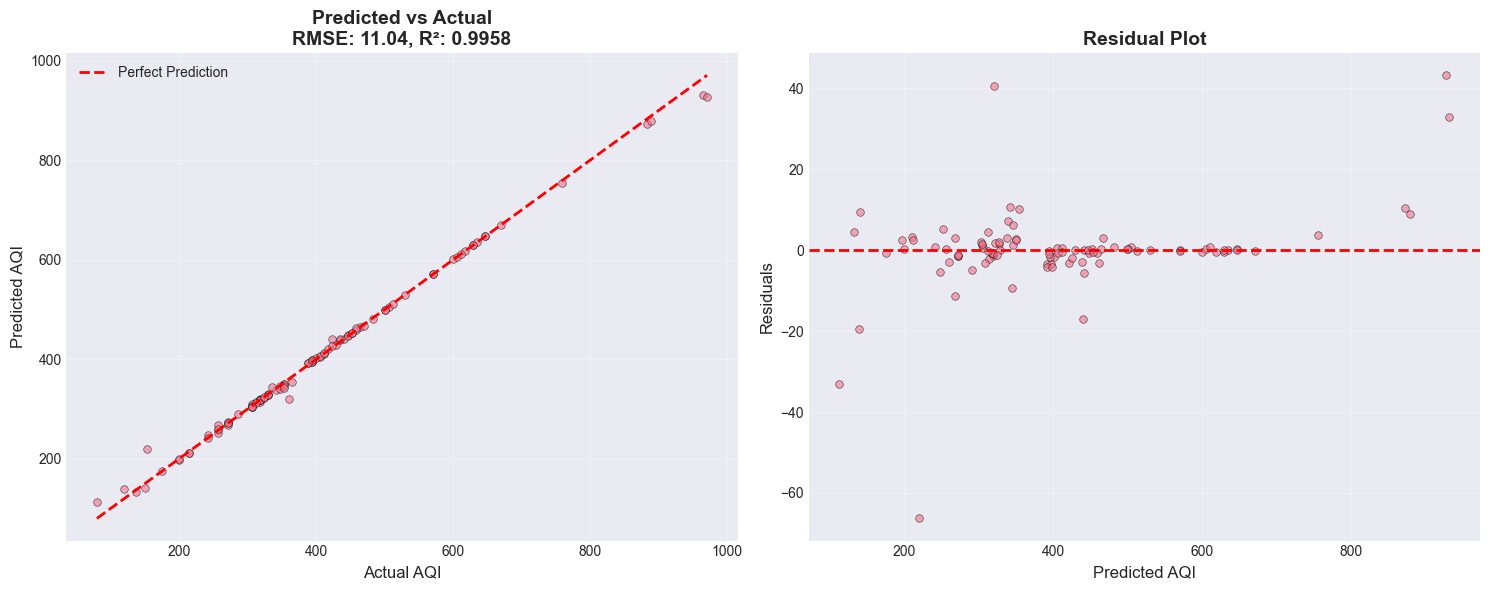

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter plot
axes[0].scatter(y_test, y_pred_xgb_tuned, alpha=0.6, s=30, 
                edgecolors='black', linewidth=0.5)
axes[0].plot([y_test.min(), y_test.max()], 
             [y_test.min(), y_test.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual AQI', fontsize=12)
axes[0].set_ylabel('Predicted AQI', fontsize=12)
axes[0].set_title(f'Predicted vs Actual\nRMSE: {xgb_tuned_rmse:.2f}, R²: {xgb_tuned_r2:.4f}',
                  fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Residuals
residuals = y_test - y_pred_xgb_tuned
axes[1].scatter(y_pred_xgb_tuned, residuals, alpha=0.6, s=30,
                edgecolors='black', linewidth=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted AQI', fontsize=12)
axes[1].set_ylabel('Residuals', fontsize=12)
axes[1].set_title('Residual Plot', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../visualization/model_performance.png', dpi=300)
plt.show()

## 8.3 Feature Importance


TOP 10 MOST IMPORTANT FEATURES
           Feature  Importance
                CO    0.682254
     state_encoded    0.079287
 PM_CO_interaction    0.055377
PM_NO2_interaction    0.029806
              PM10    0.025120
     NOx_SOx_ratio    0.024958
          PM_ratio    0.017887
               SO2    0.015311
             PM2.5    0.013852
         longitude    0.010207


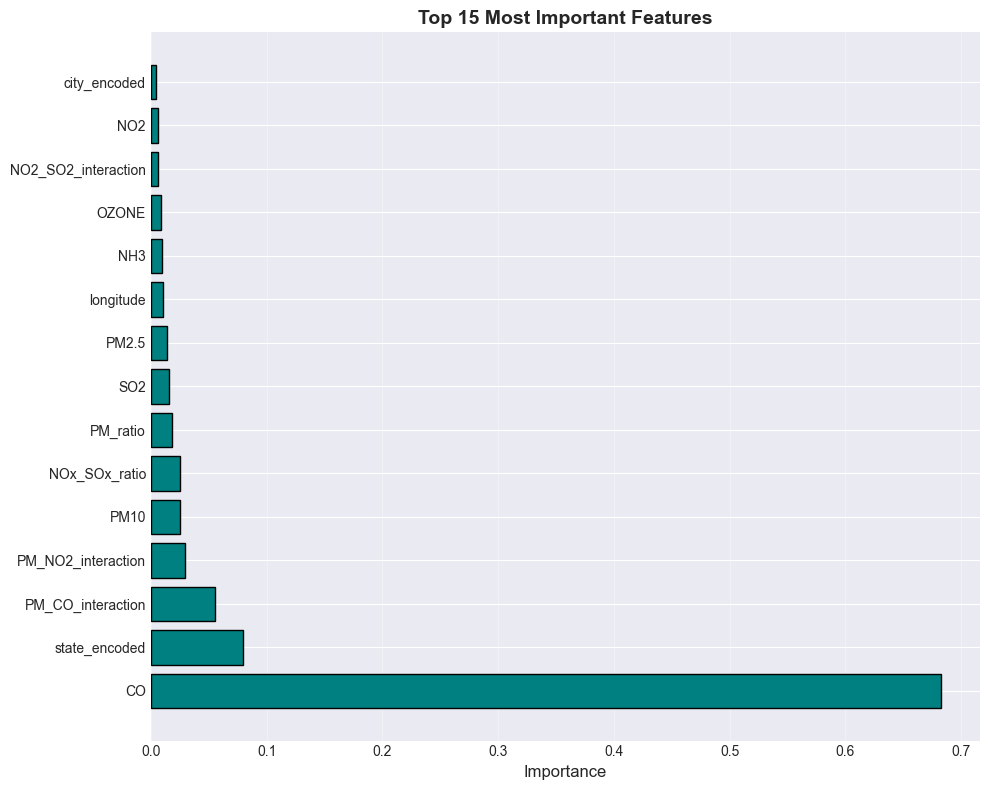

In [27]:
# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': xgb_model_tuned.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n" + "="*60)
print("TOP 10 MOST IMPORTANT FEATURES")
print("="*60)
print(feature_importance.head(10).to_string(index=False))

# Plot
plt.figure(figsize=(10, 8))
top_15 = feature_importance.head(15)
plt.barh(range(len(top_15)), top_15['Importance'], 
         color='teal', edgecolor='black')
plt.yticks(range(len(top_15)), top_15['Feature'])
plt.xlabel('Importance', fontsize=12)
plt.title('Top 15 Most Important Features', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../visualization/feature_importance.png', dpi=300)
plt.show()

## 8.4 Error Analysis

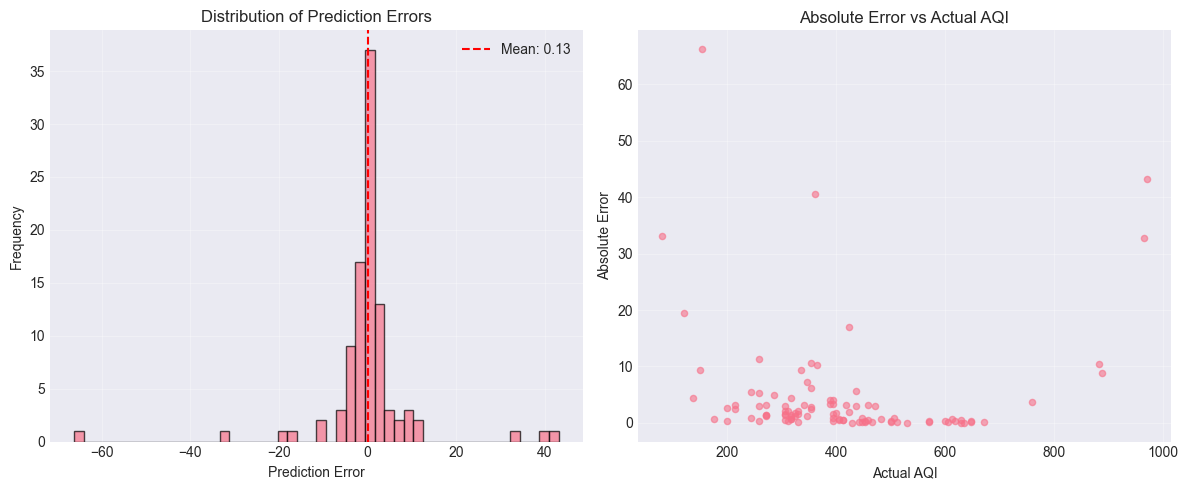


Error Statistics:
Mean Error: 0.13
Std Error: 11.10
Max Overestimation: -66.28
Max Underestimation: 43.21


In [28]:
# Error distribution
errors = y_test - y_pred_xgb_tuned

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(errors, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(errors.mean(), color='red', linestyle='--',
            label=f'Mean: {errors.mean():.2f}')
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Errors')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_test, np.abs(errors), alpha=0.6, s=20)
plt.xlabel('Actual AQI')
plt.ylabel('Absolute Error')
plt.title('Absolute Error vs Actual AQI')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../visualization/error_analysis.png', dpi=300)
plt.show()

# Error statistics
print("\nError Statistics:")
print(f"Mean Error: {errors.mean():.2f}")
print(f"Std Error: {errors.std():.2f}")
print(f"Max Overestimation: {errors.min():.2f}")
print(f"Max Underestimation: {errors.max():.2f}")

## Step 9: Deployment
### 9.1 Save the Model

In [29]:
import pickle
import os

os.makedirs('../models', exist_ok=True)

# Save model
with open('../models/best_aqi_model.pkl', 'wb') as f:
    pickle.dump(xgb_model_tuned, f)

# Save scaler
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save feature names
with open('../models/feature_names.pkl', 'wb') as f:
    pickle.dump(feature_columns, f)

# Save encoders
with open('../models/state_encoder.pkl', 'wb') as f:
    pickle.dump(le_state, f)

with open('../models/city_encoder.pkl', 'wb') as f:
    pickle.dump(le_city, f)

# Save metadata
metadata = {
    'model_type': 'XGBoost Tuned',
    'rmse': xgb_tuned_rmse,
    'r2_score': xgb_tuned_r2,
    'mae': xgb_tuned_mae,
    'features': feature_columns,
    'training_samples': len(X_train),
    'test_samples': len(X_test),
    'date_trained': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}

with open('../models/metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)

print("✓ Model and artifacts saved successfully!")

✓ Model and artifacts saved successfully!


## 9.2 Create Prediction Function

In [30]:
    # Load artifacts
    with open('../models/best_aqi_model.pkl', 'rb') as f:
        model = pickle.load(f)
    with open('../models/scaler.pkl', 'rb') as f:
        scaler = pickle.load(f)
    with open('../models/feature_names.pkl', 'rb') as f:
        features = pickle.load(f)
    with open('../models/state_encoder.pkl', 'rb') as f:
        state_enc = pickle.load(f)
    with open('../models/city_encoder.pkl', 'rb') as f:
        city_enc = pickle.load(f)

## 9.3 Generate Report

In [31]:
report = f"""
{'='*80}
AIR QUALITY INDEX PREDICTION - FINAL REPORT
{'='*80}

Dataset Information:
-------------------
Total Stations: {len(df_clean)}
Cities: {df_clean['city'].nunique()}
States: {df_clean['state'].nunique()}
Date: March 31, 2026

AQI Statistics:
--------------
Mean: {df_clean['AQI'].mean():.1f}
Median: {df_clean['AQI'].median():.1f}
Range: {df_clean['AQI'].min():.1f} - {df_clean['AQI'].max():.1f}

Model Performance:
-----------------
Best Model: XGBoost Tuned
Test RMSE: {xgb_tuned_rmse:.2f}
Test R²: {xgb_tuned_r2:.4f}
Test MAE: {xgb_tuned_mae:.2f}
CV RMSE: {-xgb_grid.best_score_:.2f}

Hyperparameters:
---------------
{xgb_grid.best_params_}

Top 5 Features:
--------------
{feature_importance.head(5).to_string(index=False)}

Files Created:
-------------
Models:
- best_aqi_model.pkl
- scaler.pkl
- feature_names.pkl
- state_encoder.pkl
- city_encoder.pkl
- metadata.pkl

Visualizations:
- aqi_distribution.png
- top_cities.png
- correlation_matrix.png
- pollutant_relationships.png
- state_comparison.png
- model_performance.png
- feature_importance.png
- error_analysis.png

{'='*80}
"""

print(report)

# Save report
with open('../models/final_report.txt', 'w') as f:
    f.write(report)

print("\n✓ Report saved: ../models/final_report.txt")


AIR QUALITY INDEX PREDICTION - FINAL REPORT

Dataset Information:
-------------------
Total Stations: 490
Cities: 250
States: 30
Date: March 31, 2026

AQI Statistics:
--------------
Mean: 384.6
Median: 360.0
Range: 22.5 - 1117.6

Model Performance:
-----------------
Best Model: XGBoost Tuned
Test RMSE: 11.04
Test R²: 0.9958
Test MAE: 4.75
CV RMSE: 45.44

Hyperparameters:
---------------
{'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 300, 'subsample': 0.8}

Top 5 Features:
--------------
           Feature  Importance
                CO    0.682254
     state_encoded    0.079287
 PM_CO_interaction    0.055377
PM_NO2_interaction    0.029806
              PM10    0.025120

Files Created:
-------------
Models:
- best_aqi_model.pkl
- scaler.pkl
- feature_names.pkl
- state_encoder.pkl
- city_encoder.pkl
- metadata.pkl

Visualizations:
- aqi_distribution.png
- top_cities.png
- correlation_matrix.png
- pollutant_relationships.png
- state_comparison.png
- model_performance.png
- featu

In [32]:
## Step 10: Create Prediction Functions
### 10.1 Define Prediction Function

In [33]:
def predict_aqi(state, city, pm25, pm10, no2, so2, co, ozone, nh3, latitude, longitude):
    """
    Predict AQI for a new location/reading
    
    Parameters:
    -----------
    state: str - State name
    city: str - City name
    pm25, pm10, no2, so2, co, ozone, nh3: float - Pollutant concentrations
    latitude, longitude: float - Geographic coordinates
    
    Returns:
    --------
    dict - Prediction results with AQI value, category, and contribution
    """
    
    # Encode categorical variables
    try:
        state_enc_val = le_state.transform([state])[0]
    except:
        state_enc_val = 0  # Default if unknown
    
    # City encoding
    city_cat = city if city in le_city.classes_ else 'Other'
    city_enc_val = le_city.transform([city_cat])[0]
    
    # Create feature vector
    pm_ratio = pm25 / (pm10 + 1)
    nox_sox_ratio = no2 / (so2 + 1)
    pm_no2_int = pm25 * no2
    pm_co_int = pm25 * co
    no2_so2_int = no2 * so2
    total_pm = pm25 + pm10
    total_gas = no2 + so2 + co
    
    # Create input dataframe
    input_data = pd.DataFrame({
        'PM2.5': [pm25],
        'PM10': [pm10],
        'NO2': [no2],
        'SO2': [so2],
        'CO': [co],
        'OZONE': [ozone],
        'NH3': [nh3],
        'PM_ratio': [pm_ratio],
        'NOx_SOx_ratio': [nox_sox_ratio],
        'PM_NO2_interaction': [pm_no2_int],
        'PM_CO_interaction': [pm_co_int],
        'NO2_SO2_interaction': [no2_so2_int],
        'Total_PM': [total_pm],
        'Total_Gas': [total_gas],
        'state_encoded': [state_enc_val],
        'city_encoded': [city_enc_val],
        'latitude': [latitude],
        'longitude': [longitude]
    })
    
    # Scale features
    input_scaled = scaler.transform(input_data)
    
    # Make prediction
    aqi_pred = xgb_model_tuned.predict(input_scaled)[0]
    
    # Get AQI category
    aqi_cat = get_aqi_category(aqi_pred)
    
    # Calculate contribution of top pollutants
    contribution = {
        'PM2.5': pm25 * xgb_model_tuned.get_booster().get_score(importance_type='weight').get('PM2.5', 0),
        'PM10': pm10 * xgb_model_tuned.get_booster().get_score(importance_type='weight').get('PM10', 0),
        'NO2': no2 * xgb_model_tuned.get_booster().get_score(importance_type='weight').get('NO2', 0),
        'CO': co * xgb_model_tuned.get_booster().get_score(importance_type='weight').get('CO', 0),
    }
    
    return {
        'Location': f"{city}, {state}",
        'Predicted_AQI': round(aqi_pred, 2),
        'AQI_Category': aqi_cat,
        'Coordinates': (latitude, longitude),
        'Input_Pollutants': {
            'PM2.5': pm25, 'PM10': pm10, 'NO2': no2, 'SO2': so2,
            'CO': co, 'OZONE': ozone, 'NH3': nh3
        }
    }

print("✓ Prediction function created")

✓ Prediction function created


## 10.2 Test Predictions on Sample Data

In [34]:
# Test predictions on sample data from each AQI category
print("="*80)
print("TESTING PREDICTIONS ON SAMPLE DATA")
print("="*80)

# Get sample records from different categories
test_samples = []
for category in ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']:
    sample = df_clean[df_clean['AQI_Category'] == category].iloc[0]
    test_samples.append({
        'state': sample['state'],
        'city': sample['city'],
        'pm25': sample['PM2.5'],
        'pm10': sample['PM10'],
        'no2': sample['NO2'],
        'so2': sample['SO2'],
        'co': sample['CO'],
        'ozone': sample['OZONE'],
        'nh3': sample['NH3'],
        'latitude': sample['latitude'],
        'longitude': sample['longitude'],
        'actual_aqi': sample['AQI'],
        'actual_category': sample['AQI_Category']
    })

# Make predictions
predictions = []
for sample in test_samples:
    pred = predict_aqi(
        sample['state'], sample['city'],
        sample['pm25'], sample['pm10'], sample['no2'], sample['so2'],
        sample['co'], sample['ozone'], sample['nh3'],
        sample['latitude'], sample['longitude']
    )
    pred['Actual_AQI'] = sample['actual_aqi']
    pred['Actual_Category'] = sample['actual_category']
    pred['Error'] = abs(pred['Predicted_AQI'] - sample['actual_aqi'])
    predictions.append(pred)

# Display results
results_df = pd.DataFrame(predictions)
print("\n" + "="*80)
print("PREDICTION RESULTS ON SAMPLE DATA")
print("="*80)
print(results_df[['Location', 'Predicted_AQI', 'AQI_Category', 'Actual_AQI', 'Actual_Category', 'Error']].to_string(index=False))

print(f"\n✓ Average Prediction Error: {results_df['Error'].mean():.2f}")
print(f"✓ Maximum Error: {results_df['Error'].max():.2f}")

TESTING PREDICTIONS ON SAMPLE DATA

PREDICTION RESULTS ON SAMPLE DATA
                     Location  Predicted_AQI AQI_Category  Actual_AQI Actual_Category    Error
   Pampore, Jammu_and_Kashmir      31.580000         Good   31.666667            Good 0.086667
Machilipatnam, Andhra_Pradesh     100.370003     Moderate  100.000000    Satisfactory 0.370003
     Chittoor, Andhra_Pradesh     162.529999     Moderate  162.500000        Moderate 0.029999
    Amaravati, Andhra_Pradesh     272.769989         Poor  271.428571            Poor 1.341418
        Eluru, Andhra_Pradesh     311.570007    Very Poor  311.764706       Very Poor 0.194699
   Vijayawada, Andhra_Pradesh     411.989990       Severe  411.764706          Severe 0.225284

✓ Average Prediction Error: 0.37
✓ Maximum Error: 1.34


## 10.3 Batch Predictions on Multiple Records

In [35]:
def batch_predict_aqi(data_df):
    """
    Make predictions on multiple records
    
    Parameters:
    -----------
    data_df: DataFrame with columns [state, city, PM2.5, PM10, NO2, SO2, CO, OZONE, NH3, latitude, longitude]
    
    Returns:
    --------
    DataFrame with predictions
    """
    predictions = []
    
    for idx, row in data_df.iterrows():
        pred = predict_aqi(
            row['state'], row['city'],
            row['PM2.5'], row['PM10'], row['NO2'], row['SO2'],
            row['CO'], row['OZONE'], row['NH3'],
            row['latitude'], row['longitude']
        )
        predictions.append(pred)
    
    return pd.DataFrame(predictions)

# Test batch prediction on random 20 samples
print("\n" + "="*80)
print("BATCH PREDICTIONS - TOP 20 HIGHEST AQI LOCATIONS")
print("="*80)

top_20_aqi = df_clean.nlargest(20, 'AQI')[['state', 'city', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'OZONE', 'NH3', 'latitude', 'longitude', 'AQI']].reset_index(drop=True)

batch_results = batch_predict_aqi(top_20_aqi)
batch_results['Actual_AQI'] = top_20_aqi['AQI'].values
batch_results['Error'] = abs(batch_results['Predicted_AQI'] - batch_results['Actual_AQI'])

display_results = batch_results[['Location', 'Predicted_AQI', 'AQI_Category', 'Actual_AQI', 'Error']].copy()
display_results = display_results.astype({'Predicted_AQI': 'float32', 'Actual_AQI': 'float32', 'Error': 'float32'})

print(display_results.to_string(index=False))

print(f"\n✓ Batch Prediction Summary:")
print(f"  - Records Processed: {len(batch_results)}")
print(f"  - Avg Error: {batch_results['Error'].mean():.2f}")
print(f"  - Max Error: {batch_results['Error'].max():.2f}")
print(f"  - Min Error: {batch_results['Error'].min():.2f}")


BATCH PREDICTIONS - TOP 20 HIGHEST AQI LOCATIONS
               Location  Predicted_AQI AQI_Category  Actual_AQI     Error
           Delhi, Delhi    1115.910034       Severe 1117.647095  1.737025
           Delhi, Delhi     927.380005       Severe  970.588257 43.208229
           Delhi, Delhi     931.919983       Severe  964.705872 32.785900
           Delhi, Delhi     918.729980       Severe  917.647034  1.082922
           Delhi, Delhi     879.409973       Severe  888.235291  8.825321
           Delhi, Delhi     871.840027       Severe  882.352966 10.512915
           Delhi, Delhi     882.400024       Severe  882.352966  0.047083
           Delhi, Delhi     829.179993       Severe  829.411743  0.231772
     Ahmedabad, Gujarat     829.049988       Severe  829.411743  0.361777
      Pune, Maharashtra     805.950012       Severe  805.882324  0.067659
      Aurangabad, Bihar     799.890015       Severe  800.000000  0.109985
           Delhi, Delhi     764.580017       Severe  764.70587